## Import libraries

In [3]:
# For data manipulation
import pandas as pd
import numpy as np

In [4]:
# Input data 
INPUT_PATH_family = "cleaned data/family_good.csv"
INPUT_PATH_lab = "cleaned data/lab_final.csv"
INPUT_PATH_patient = "cleaned data/patient_good.csv"
INPUT_PATH_encounter = "cleaned data/encounter_dx_final.csv"

In [5]:
# Load dataset(s)
patient = pd.read_csv(INPUT_PATH_patient, sep = "|") 
patient.columns = patient.columns.str.strip('"')
patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352161 entries, 0 to 352160
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Patient_ID  352161 non-null  int64  
 1   Sex         352121 non-null  object 
 2   BirthYear   352020 non-null  float64
 3   BirthMonth  211940 non-null  float64
 4   OptedOut    352161 non-null  bool   
 5   OptOutDate  0 non-null       float64
dtypes: bool(1), float64(3), int64(1), object(1)
memory usage: 13.8+ MB


In [6]:
encounter = pd.read_csv(INPUT_PATH_encounter, sep = "|", low_memory=False) 
encounter.columns = encounter.columns.str.strip('"')
encounter.head(10)

,EncounterDiagnosis_ID,Network_ID,Site_ID,Patient_ID,Encounter_ID,Cycle_ID,DiagnosisText_orig,DiagnosisText_calc,DiagnosisCodeType_orig,DiagnosisCodeType_calc,DiagnosisCode_orig,DiagnosisCode_calc,DateCreated
0,1002000000000002,1,1000000000000004,1002000000032183,1.002000e+15,2015-Q2,Diabetes Mellitus -Type 1- Insulin Dependent,TYPE I DIABETES MELLITUS [INSULIN DEPENDENT TY...,ICD9,ICD9,250.01,250.01,2008-08-05 00:00:00
1,1002000000000003,1,1000000000000004,1002000000032183,1.002000e+15,2015-Q2,Hep A and Hep B Combined Vaccine,NaN,NaN,NaN,NaN,NaN,2008-08-05 00:00:00
2,1002000000000004,1,1000000000000004,1002000000032183,1.002000e+15,2015-Q2,Pre Natal Form,NaN,NaN,NaN,NaN,NaN,2008-08-05 00:00:00
3,1002000000000005,1,1000000000000004,1002000000013966,1.002000e+15,2015-Q2,general symptoms genx,GENERAL SYMPTOMS,ICD9,ICD9,780,780,2008-09-04 00:00:00
4,1002000000000006,1,1000000000000004,1002000000024045,1.002000e+15,2015-Q2,Obesity,OVERWEIGHT AND OBESITY,ICD9,ICD9,278.0,278.0,2008-09-11 00:00:00
5,1002000000000007,1,1000000000000004,1002000000006790,1.002000e+15,2015-Q2,examination (general) (routine),ROUTINE GENERAL MEDICAL EXAMINATION AT A HEALT...,ICD9,ICD9,V70.0,V70.0,2008-09-12 00:00:00
6,1002000000000008,1,1000000000000004,1002000000005174,1.002000e+15,2015-Q2,Esophageal Cancer,MALIGNANT NEOPLASM OF ESOPHAGUS,ICD9,ICD9,150,150,2008-09-05 00:00:00
7,1002000000000009,1,1000000000000004,1002000000032183,1.002000e+15,2015-Q2,Headache,HEADACHE,ICD9,ICD9,784.0,784.0,2008-08-07 00:00:00
8,1002000000000010,1,1000000000000004,1002000000015606,1.002000e+15,2015-Q2,examination (general) (routine),ROUTINE GENERAL MEDICAL EXAMINATION AT A HEALT...,ICD9,ICD9,V70.0,V70.0,2008-09-11 00:00:00
9,1002000000000011,1,1000000000000004,1002000000014862,1.002000e+15,2015-Q2,Abnormal paps,NaN,NaN,NaN,NaN,NaN,2008-09-05 00:00:00


In [7]:
# Check columns types
encounter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12471785 entries, 0 to 12471784
Data columns (total 13 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   EncounterDiagnosis_ID   int64  
 1   Network_ID              int64  
 2   Site_ID                 int64  
 3   Patient_ID              int64  
 4   Encounter_ID            float64
 5   Cycle_ID                object 
 6   DiagnosisText_orig      object 
 7   DiagnosisText_calc      object 
 8   DiagnosisCodeType_orig  object 
 9   DiagnosisCodeType_calc  object 
 10  DiagnosisCode_orig      object 
 11  DiagnosisCode_calc      object 
 12  DateCreated             object 
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ GB


In [8]:
### change columns in encounter table, DateCreated 
encounter['DateCreated'] = pd.to_datetime(encounter['DateCreated'], format = 'mixed', errors = 'coerce')

In [9]:
# cleaned encounter, based on Data Dictionary, the _calc columns are the _orig column into consistent text, so we only
# incude the _calc columns in the cleaned encounter table 
encounter_clean = encounter[['Patient_ID', 'Encounter_ID', 'DiagnosisText_calc', 
                             'DiagnosisCodeType_calc', 'DiagnosisCode_calc', 'DateCreated']]
encounter_clean.head(10)

,Patient_ID,Encounter_ID,DiagnosisText_calc,DiagnosisCodeType_calc,DiagnosisCode_calc,DateCreated
0,1002000000032183,1.002000e+15,TYPE I DIABETES MELLITUS [INSULIN DEPENDENT TY...,ICD9,250.01,2008-08-05
1,1002000000032183,1.002000e+15,NaN,NaN,NaN,2008-08-05
2,1002000000032183,1.002000e+15,NaN,NaN,NaN,2008-08-05
3,1002000000013966,1.002000e+15,GENERAL SYMPTOMS,ICD9,780,2008-09-04
4,1002000000024045,1.002000e+15,OVERWEIGHT AND OBESITY,ICD9,278.0,2008-09-11
5,1002000000006790,1.002000e+15,ROUTINE GENERAL MEDICAL EXAMINATION AT A HEALT...,ICD9,V70.0,2008-09-12
6,1002000000005174,1.002000e+15,MALIGNANT NEOPLASM OF ESOPHAGUS,ICD9,150,2008-09-05
7,1002000000032183,1.002000e+15,HEADACHE,ICD9,784.0,2008-08-07
8,1002000000015606,1.002000e+15,ROUTINE GENERAL MEDICAL EXAMINATION AT A HEALT...,ICD9,V70.0,2008-09-11
9,1002000000014862,1.002000e+15,NaN,NaN,NaN,2008-09-05


In [10]:
encounter_clean['DiagnosisCodeType_calc'].unique() # checked: only ICD9 code type included 
encounter_clean['Patient_ID'].nunique() # total number of patients (unfiltered): 352161, consists to patient table 

352161

In [11]:
### In ICD9 code, start with 'V' indicates rountine medical exams, 'E' indicates external causes of injury. 
# Check numbers first 
encounter_clean['DiagnosisCode_calc'].str.startswith('V').sum()
# 863195/12471785=0.069
encounter_clean['DiagnosisCode_calc'].str.startswith('E').sum() # 4804

863195

In [14]:
# Drop the rows start with 'V' or 'E' 
encounter_clean = encounter_clean[
    ~encounter['DiagnosisCode_calc'].str.startswith(('V', 'E'), na=False)
]
encounter_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11603786 entries, 0 to 12471784
Data columns (total 6 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Patient_ID              int64         
 1   Encounter_ID            float64       
 2   DiagnosisText_calc      object        
 3   DiagnosisCodeType_calc  object        
 4   DiagnosisCode_calc      object        
 5   DateCreated             datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 619.7+ MB


In [21]:
# convert to strings 
encounter_clean['DiagnosisCode_calc'] = encounter_clean['DiagnosisCode_calc'].astype(str)

def classify_icd(code):
    code = code.strip()
    
    # Depression
    if (
        code.startswith('296.2') or
        code.startswith('296.3') or
        code == '300.4' or
        code == '311' or
        code == '309.0'
    ):
        return 'Depression'
    
    # Asthma (493.x)
    if code.startswith('493'):
        return 'Asthma'
    
    # COPD (490–496)
    try:
        base = float(code[:3]) 
        if 490 <= base <= 496:
            return 'COPD'
    except:
        pass
    
    return np.nan

In [22]:
# Add a new column to indicate the condition 
encounter_clean['condition'] = encounter_clean['DiagnosisCode_calc'].apply(classify_icd)
encounter_clean.head(10)

,Patient_ID,Encounter_ID,DiagnosisText_calc,DiagnosisCodeType_calc,DiagnosisCode_calc,DateCreated,condition
0,1002000000032183,1.002000e+15,TYPE I DIABETES MELLITUS [INSULIN DEPENDENT TY...,ICD9,250.01,2008-08-05,NaN
1,1002000000032183,1.002000e+15,NaN,NaN,nan,2008-08-05,NaN
2,1002000000032183,1.002000e+15,NaN,NaN,nan,2008-08-05,NaN
3,1002000000013966,1.002000e+15,GENERAL SYMPTOMS,ICD9,780,2008-09-04,NaN
4,1002000000024045,1.002000e+15,OVERWEIGHT AND OBESITY,ICD9,278.0,2008-09-11,NaN
6,1002000000005174,1.002000e+15,MALIGNANT NEOPLASM OF ESOPHAGUS,ICD9,150,2008-09-05,NaN
7,1002000000032183,1.002000e+15,HEADACHE,ICD9,784.0,2008-08-07,NaN
9,1002000000014862,1.002000e+15,NaN,NaN,nan,2008-09-05,NaN
10,1002000000010165,1.002000e+15,OTHER AND UNSPECIFIED HYPERLIPIDEMIA,ICD9,272.4,2008-09-05,NaN
11,1002000000006770,1.002000e+15,NaN,NaN,nan,2008-09-12,NaN


In [24]:
# Count numbers for each condition
encounter_clean['condition'].value_counts(dropna=False)

condition
NaN           11192484
Depression      252969
Asthma           85503
COPD             72830
Name: count, dtype: int64

### Find first occassion of each condition 

In [39]:
# Asthma
asthma = encounter_clean[encounter_clean['condition'] == 'Asthma']
first_asthma = asthma.groupby('Patient_ID')['DateCreated'].min().reset_index()
first_asthma.columns = ['Patient_ID', 'asthma_date']

In [40]:
# COPD
copd = encounter_clean[encounter_clean['condition'] == 'COPD']
first_copd = copd.groupby('Patient_ID')['DateCreated'].min().reset_index()
first_copd.columns = ['Patient_ID', 'copd_date']

In [41]:
# Depression
depression = encounter_clean[encounter_clean['condition'] == 'Depression']
first_depression = depression.groupby('Patient_ID')['DateCreated'].min().reset_index()
first_depression.columns = ['Patient_ID', 'depression_date']

In [42]:
# Merge Exposure 
exposure = first_asthma.merge(first_copd, on='Patient_ID', how='outer')

# Non-Overlapping
exposure = exposure[
    ~(
        exposure['asthma_date'].notna() &
        exposure['copd_date'].notna()
    )
]

In [43]:
# Define exposure and index date (baseline)
exposure['exposure'] = np.where(
    exposure['asthma_date'].notna(), 'Asthma',
    'COPD'
)

exposure['index_date'] = exposure[['asthma_date', 'copd_date']].min(axis=1)

In [45]:
# merge depression, and exclude population with depression prior to ashtma/copd 
exposure = exposure.merge(first_depression, on='Patient_ID', how='left')

exposure = exposure[
    (exposure['depression_date'].isna()) |
    (exposure['depression_date'] >= exposure['index_date'])
]

In [47]:
# define event 
exposure['event'] = np.where(
    exposure['depression_date'].notna(),
    1, 0
)

In [48]:
# Patient-level dataframe 
final_df = exposure.merge(
    patient[['Patient_ID', 'Sex']],
    left_on='Patient_ID',
    right_on='Patient_ID',
    how='left'
)

In [57]:
final_df = final_df.merge(
    first_depression,
    on='Patient_ID',
    how='left'
)


In [58]:
# censor date is the max(datecreated)
censor_date = pd.to_datetime('2015-07-21')

# Define end_date, either the depression date, or the censor date 
final_df['end_date'] = np.where(
    final_df['depression_date'].notna(),
    final_df['depression_date'],
    censor_date
)

# Time interval between index date and end date 
final_df['time'] = (
    pd.to_datetime(final_df['end_date']) - 
    pd.to_datetime(final_df['index_date'])
).dt.days

final_df = final_df[[
    'Patient_ID', 'Sex', 'exposure', 'index_date', 'event', 'end_date', 'time'
]]

In [65]:
OUTPUT_PATH = 'cleaned data/final_df.csv'
final_df.to_csv(OUTPUT_PATH, index=False)

In [67]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35366 entries, 0 to 35365
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Patient_ID  35366 non-null  int64         
 1   Sex         35366 non-null  object        
 2   exposure    35366 non-null  object        
 3   index_date  35366 non-null  datetime64[ns]
 4   event       35366 non-null  int64         
 5   end_date    35366 non-null  object        
 6   time        35366 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 1.9+ MB


### Survival Analysis

In [64]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

### Kaplan-Meier Plot 

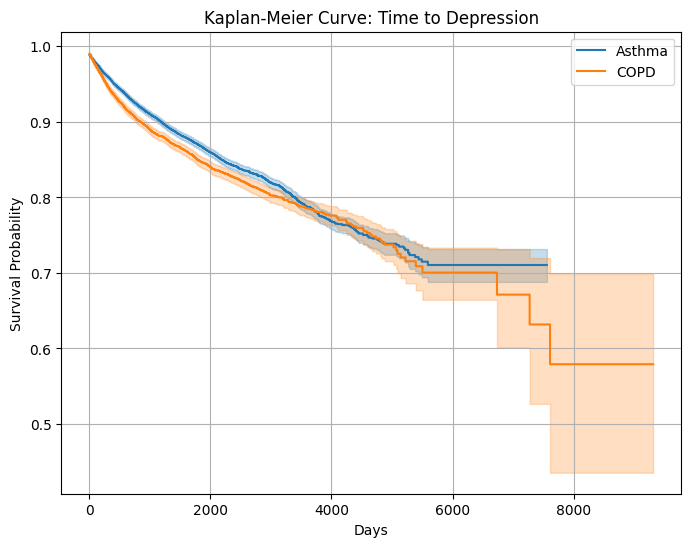

In [68]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for group in ['Asthma', 'COPD']:
    mask = final_df['exposure'] == group
    
    kmf.fit(
        durations=final_df.loc[mask, 'time'],
        event_observed=final_df.loc[mask, 'event'],
        label=group
    )
    
    kmf.plot_survival_function(ci_show=True)

plt.title('Kaplan-Meier Curve: Time to Depression')
plt.xlabel('Days')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.show()

### Log-Rank test 

In [70]:
from lifelines.statistics import logrank_test

asthma = final_df[final_df['exposure'] == 'Asthma']
copd   = final_df[final_df['exposure'] == 'COPD']

result = logrank_test(
    asthma['time'],
    copd['time'],
    event_observed_A=asthma['event'],
    event_observed_B=copd['event']
)

print(result.summary)

   test_statistic         p   -log2(p)
0       16.479124  0.000049  14.311313
